# track_tongue.ipynb — 혀 트래킹 시각 검증

`track_tongue.py`(optical-flow 라벨 전파)를 눈으로 확인하는 노트북.
**clean 기준 프레임**의 혀 라벨을 앞뒤 프레임으로 전파 → GT와 겹쳐 비교.

순서대로 실행하세요. 맨 아래 config(`SUBJECT`, `REFS`)만 바꾸면 됩니다.

In [3]:
%matplotlib inline
import os, sys, glob, re, importlib.util
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours
plt.rcParams["figure.dpi"] = 110

REPO = Path.cwd()
assert (REPO/"track_tongue.py").exists(), f"repo 루트에서 실행 (현재 {REPO})"
# track_tongue.py 를 모듈로 로드
spec = importlib.util.spec_from_file_location("track_tongue", str(REPO/"track_tongue.py"))
tt = importlib.util.module_from_spec(spec); spec.loader.exec_module(tt)
print("track_tongue 로드 OK:", [f for f in dir(tt) if not f.startswith("_")][:8])

track_tongue 로드 OK: ['argparse', 'cv2', 'dice', 'farneback', 'glob', 'load_gray_sequence', 'load_gt_tongue', 'main']


## 1. 설정 + 전파 실행
`SUBJECT` 와 기준 프레임 `REFS` 를 정하고 전파. GT(label 4)를 기준으로 쓰는 데모.
(실사용: 손으로 그린 라벨 폴더가 있으면 `LABEL_DIR` 지정 → 부위 라벨도 전파)

In [ ]:
SUBJECT = "Subject3"
REFS    = [11, 21, 52, 59]      # clean(혀가 또렷한) 프레임 번호들
LABEL_DIR = ""                  # "" 이면 GT 혀(binary). 부위 라벨 PNG 폴더면 그걸 사용

sub_dir = REPO/"datasets"/"MRI_SSFP_10fps"/SUBJECT
seg_dir = REPO/"datasets"/"GT_Segmentations"/SUBJECT
grays = tt.load_gray_sequence(str(sub_dir)); order = sorted(grays)
gt = tt.load_gt_tongue(str(seg_dir)) if seg_dir.is_dir() else {}
assert order, f"png 없음 — 먼저 datasets/prepare.py 실행 ({sub_dir})"

if LABEL_DIR:
    import cv2
    refs = {r: cv2.imread(str(Path(LABEL_DIR)/f"image_{r}.png"), cv2.IMREAD_GRAYSCALE).astype(np.int32) for r in REFS}
else:
    refs = {r: gt[r] for r in REFS if r in gt}

result = tt.propagate_labels(grays, order, refs)     # {frame: label img}
if gt:
    nonref = [i for i in order if i not in refs]
    dloc = {i: tt.dice(result[i] > 0, gt[i]) for i in order}
    print(f"frames={len(order)}  refs={sorted(refs)}")
    print(f"non-ref Dice: mean={np.mean([dloc[i] for i in nonref]):.3f}  min={np.min([dloc[i] for i in nonref]):.3f}")

frames=71  refs=[1, 20, 40, 60]
non-ref Dice: mean=0.929  min=0.861


## 2. 오버레이 그리드 (노랑=전파, 빨강=GT)
시퀀스 전체에서 고르게 몇 프레임을 골라 전파 결과와 GT contour 를 겹쳐 본다.

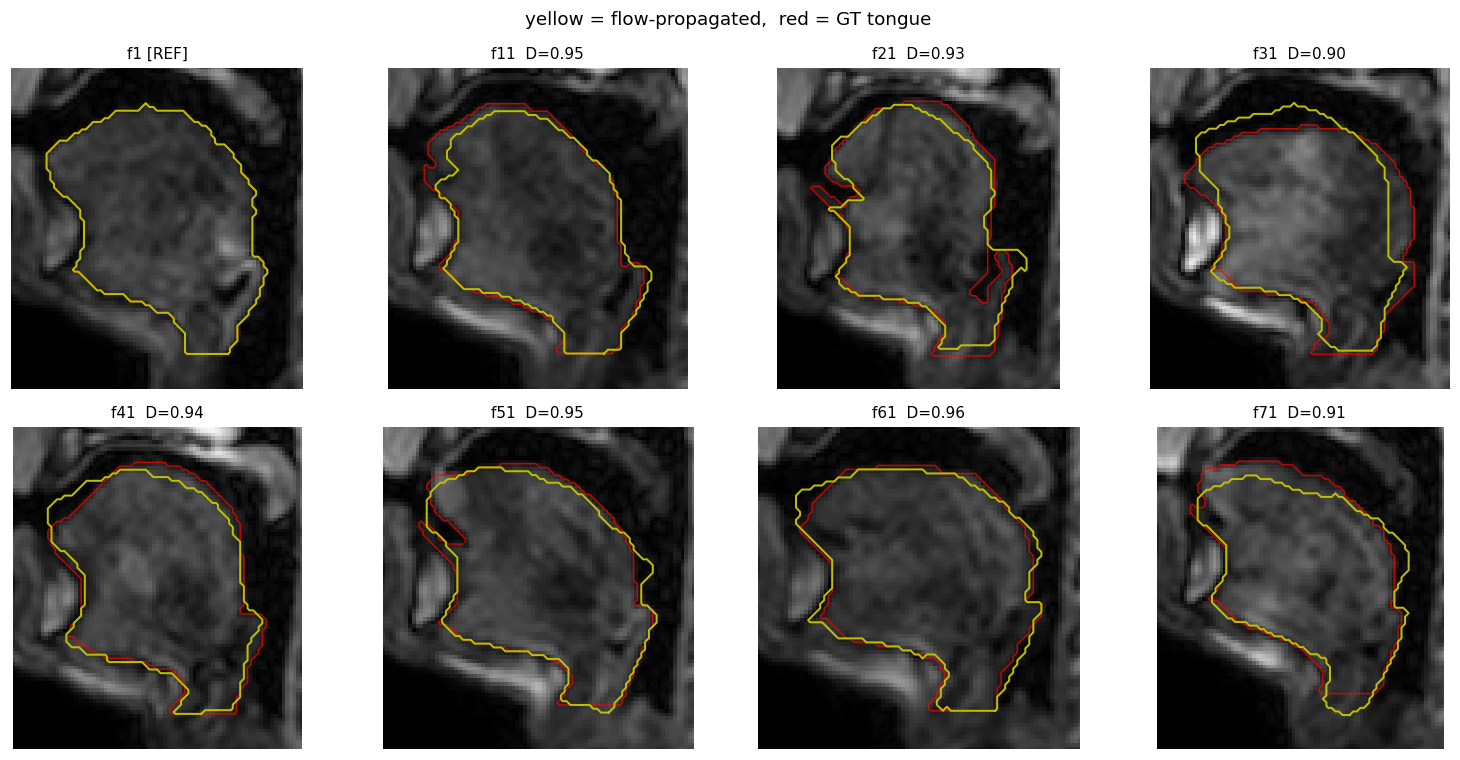

In [5]:
sel = [order[int(round(t))] for t in np.linspace(0, len(order)-1, 8)]
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for a, i in zip(ax.ravel(), sel):
    a.imshow(grays[i], cmap="gray")
    if gt:
        for ct in find_contours(gt[i].astype(float), 0.5): a.plot(ct[:,1], ct[:,0], "r-", lw=1, alpha=.7)
    for ct in find_contours((result[i]>0).astype(float), 0.5): a.plot(ct[:,1], ct[:,0], "y-", lw=1.3)
    m = (result[i]>0) | (gt.get(i, np.zeros_like(result[i]))>0)
    ys, xs = np.where(m); a.set_xlim(xs.min()-10, xs.max()+10); a.set_ylim(ys.max()+10, ys.min()-10)
    tag = " [REF]" if i in refs else (f"  D={dloc[i]:.2f}" if gt else "")
    a.set_title(f"f{i}{tag}", fontsize=10); a.axis("off")
fig.suptitle("yellow = flow-propagated,  red = GT tongue")
plt.tight_layout(); plt.show()

## 3. 프레임별 Dice 곡선
기준(●)에서 멀어질수록 드리프트로 Dice 가 떨어지는지 확인.

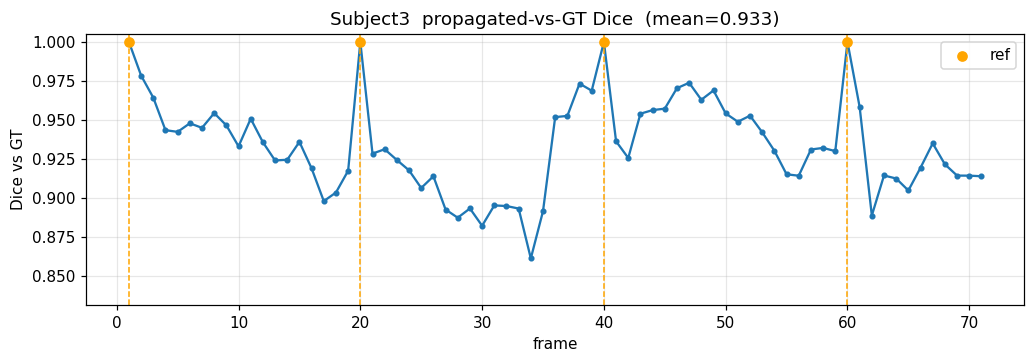

In [6]:
if gt:
    xs = order; ys = [dloc[i] for i in xs]
    plt.figure(figsize=(11,3.2))
    plt.plot(xs, ys, "-o", ms=3)
    for r in refs: plt.axvline(r, color="orange", ls="--", lw=1)
    plt.scatter(list(refs), [dloc[r] for r in refs], c="orange", zorder=5, label="ref")
    plt.ylim(min(ys)-0.03, 1.005); plt.xlabel("frame"); plt.ylabel("Dice vs GT")
    plt.title(f"{SUBJECT}  propagated-vs-GT Dice  (mean={np.mean(ys):.3f})"); plt.legend(); plt.grid(alpha=.3)
    plt.show()
else:
    print("GT 없음 — Dice 생략")

## 4. 프레임 슬라이더 (인터랙티브)
`ipywidgets` 있으면 슬라이더로 프레임을 넘겨가며 확인. 없으면 `show_frame(번호)` 로 직접 호출.

ipywidgets 없음 → show_frame(30) 처럼 직접 호출: No module named 'ipywidgets'


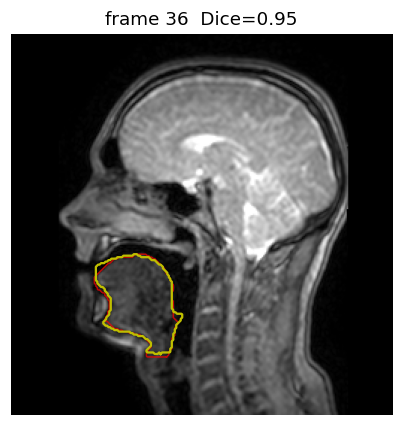

In [7]:
def show_frame(i):
    fig, a = plt.subplots(figsize=(4.5,4.5))
    a.imshow(grays[i], cmap="gray")
    if gt:
        for ct in find_contours(gt[i].astype(float),0.5): a.plot(ct[:,1],ct[:,0],"r-",lw=1,alpha=.7,label="GT")
    for ct in find_contours((result[i]>0).astype(float),0.5): a.plot(ct[:,1],ct[:,0],"y-",lw=1.5,label="propagated")
    tag=" [REF]" if i in refs else (f"  Dice={dloc[i]:.2f}" if gt else "")
    a.set_title(f"frame {i}{tag}"); a.axis("off"); plt.show()

try:
    from ipywidgets import interact, IntSlider
    interact(show_frame, i=IntSlider(min=order[0], max=order[-1], step=1, value=order[len(order)//2]))
except Exception as e:
    print("ipywidgets 없음 → show_frame(30) 처럼 직접 호출:", e)
    show_frame(order[len(order)//2])

## 5. 부위(다중 라벨) 전파 데모
기준 프레임에 여러 라벨(1=body,2=floor,3=base…)을 그려두면 부위가 함께 전파된다.
아래는 확인용으로 GT 혀를 **열 기준 3등분**해 가짜 부위 라벨을 만들어 전파.
(실사용 땐 위 `LABEL_DIR` 에 실제 부위 라벨 PNG 를 넣으면 됨)

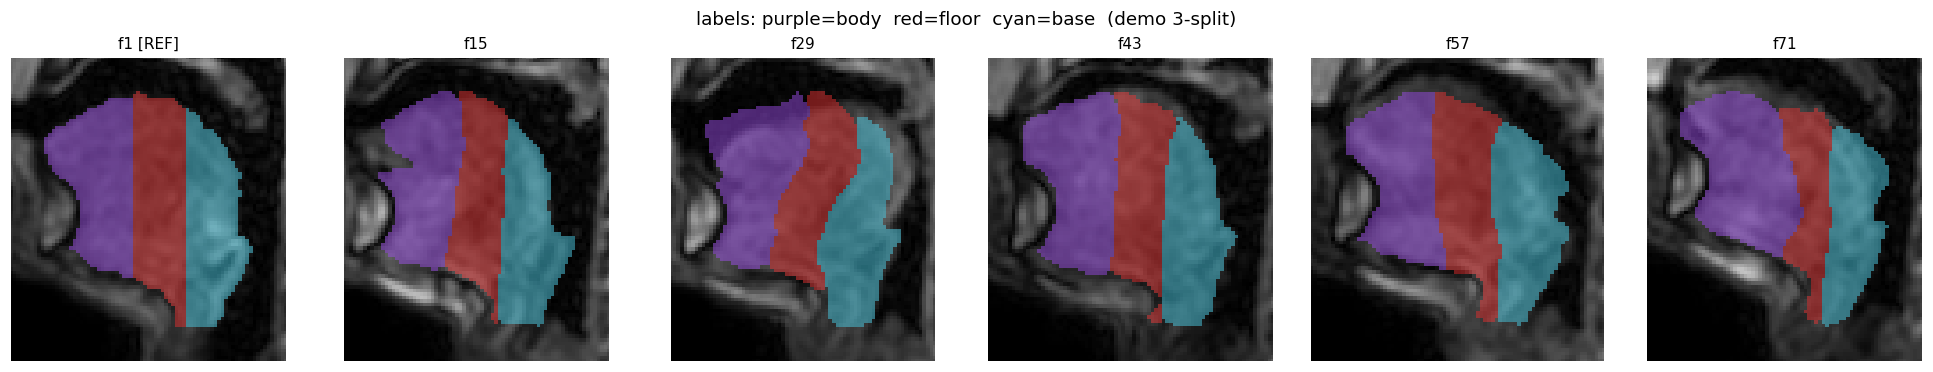

In [8]:
if gt:
    def split3(m):
        ys,xs=np.where(m>0)
        if len(xs)==0: return m.astype(np.int32)
        c1,c2=np.percentile(xs,[33,66]); lab=np.zeros_like(m,np.int32); cols=np.arange(m.shape[1])[None,:]
        lab[(m>0)&(cols<=c1)]=1; lab[(m>0)&(cols>c1)&(cols<=c2)]=2; lab[(m>0)&(cols>c2)]=3
        return lab
    refs3 = {r: split3(gt[r]) for r in REFS if r in gt}
    res3 = tt.propagate_labels(grays, order, refs3)
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap([(0,0,0,0),(0.6,0.3,0.9),(0.9,0.2,0.2),(0.3,0.8,0.9)])  # bg/보라/빨강/하늘
    sel = [order[int(round(t))] for t in np.linspace(0, len(order)-1, 6)]
    fig, ax = plt.subplots(1, len(sel), figsize=(3.0*len(sel), 3.4))
    for a, i in zip(ax, sel):
        a.imshow(grays[i], cmap="gray"); a.imshow(res3[i], cmap=cmap, vmin=0, vmax=3, alpha=0.5, interpolation="nearest")
        ys,xs=np.where(res3[i]>0); a.set_xlim(xs.min()-10,xs.max()+10); a.set_ylim(ys.max()+10,ys.min()-10)
        a.set_title(f"f{i}"+(" [REF]" if i in refs3 else ""), fontsize=10); a.axis("off")
    fig.suptitle("labels: purple=body  red=floor  cyan=base  (demo 3-split)")
    plt.tight_layout(); plt.show()
else:
    print("GT 없음 — 부위 데모 생략")